# Hummingbot Trade Profitability Analysis

Clean, run-from-top notebook to analyze fills, inventory risk, and PnL quality for one session.

Run order:
1. Parameters
2. Data load and normalization
3. Derived metrics
4. Charts and diagnostics


In [1]:
import json
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)


In [2]:
# ---- Parameters ----
DB_PATH = "/home/sophos9/quanta_mm/data/quanta-mm.sqlite".strip()
EXCHANGE = "cryptocom"
SYMBOL = "BTC-USD"
STRATEGY = None      # e.g. "avellaneda_market_making"
CONFIG_FILE = None   # e.g. "quanta_mm.yml"
START = None         # e.g. "2026-02-16 10:00:00"
END = None           # e.g. "2026-02-16 18:00:00"

# Optional hold-comparison (set to floats if you want hold-vs-strategy)
START_BASE_BALANCE = None
START_QUOTE_BALANCE = None

# Fill-quality horizons (seconds)
ADVERSE_SELECTION_WINDOWS = [5, 10, 30]


In [3]:
DB_PATH = str(Path(DB_PATH).expanduser())
assert Path(DB_PATH).exists(), f"Database not found: {DB_PATH}"
print("Using DB:", DB_PATH)


Using DB: /home/sophos9/quanta_mm/data/quanta-mm.sqlite


In [4]:
def load_trade_fills(db_path, exchange=None, symbol=None, strategy=None, config_file=None, start=None, end=None):
    conn = sqlite3.connect(db_path)
    query = """
    SELECT
      config_file_path, strategy, market, symbol, base_asset, quote_asset,
      timestamp, order_id, trade_type, order_type, price, amount,
      leverage, trade_fee, trade_fee_in_quote, exchange_trade_id, position
    FROM TradeFill
    WHERE 1=1
    """
    params = []

    if exchange:
      query += " AND market = ?"
      params.append(exchange)
    if symbol:
      query += " AND symbol = ?"
      params.append(symbol)
    if strategy:
      query += " AND strategy = ?"
      params.append(strategy)
    if config_file:
      query += " AND config_file_path LIKE ?"
      params.append(f"%{config_file}%")
    if start:
      query += " AND datetime(timestamp/1e3, 'unixepoch') >= datetime(?)"
      params.append(start)
    if end:
      query += " AND datetime(timestamp/1e3, 'unixepoch') <= datetime(?)"
      params.append(end)

    query += " ORDER BY timestamp ASC"

    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    return df


def parse_fee_in_quote(row):
    if row.get("trade_fee_in_quote") is not None and str(row.get("trade_fee_in_quote")) != "":
        try:
            return float(row["trade_fee_in_quote"])
        except Exception:
            pass

    tf = row.get("trade_fee")
    if tf is None or str(tf) == "":
        return 0.0

    try:
        tf_obj = json.loads(tf) if isinstance(tf, str) else tf
    except Exception:
        return 0.0

    percent = float(tf_obj.get("percent", 0) or 0)
    fee_quote = percent * float(row["price"]) * float(row["amount"])

    for fb in tf_obj.get("flat_fees", []) or []:
        try:
            token = fb.get("token")
            amount = float(fb.get("amount", 0) or 0)
            if token == row.get("quote_asset"):
                fee_quote += amount
        except Exception:
            continue
    return float(fee_quote)


In [5]:
df = load_trade_fills(DB_PATH, EXCHANGE, SYMBOL, STRATEGY, CONFIG_FILE, START, END)
if df.empty:
    raise RuntimeError("No trades found for the selected filters.")

# Normalize SqliteDecimal(6) fields from DB
df["price"] = pd.to_numeric(df["price"], errors="coerce") / 1e6
df["amount"] = pd.to_numeric(df["amount"], errors="coerce") / 1e6
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["dt"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True).dt.tz_convert(None)

df["is_buy"] = df["trade_type"].astype(str).str.lower().eq("buy")
df["quote_notional"] = df["price"] * df["amount"]
df["fee_quote"] = df.apply(parse_fee_in_quote, axis=1)
df["signed_quote_flow_net"] = np.where(df["is_buy"], -df["quote_notional"], df["quote_notional"]) - df["fee_quote"]
df["signed_base_delta"] = np.where(df["is_buy"], df["amount"], -df["amount"])

df = df.sort_values("dt").reset_index(drop=True)
last_price = float(df["price"].iloc[-1])
first_price = float(df["price"].iloc[0])

df["cum_base"] = df["signed_base_delta"].cumsum()
df["cum_quote_net"] = df["signed_quote_flow_net"].cumsum()
df["inventory_mtm"] = df["cum_base"] * df["price"]
df["total_pnl_proxy"] = df["cum_quote_net"] + df["inventory_mtm"]
df["equity_peak"] = df["total_pnl_proxy"].cummax()
df["drawdown"] = df["total_pnl_proxy"] - df["equity_peak"]

df["execution_cashflow"] = df["cum_quote_net"]

df["inventory_risk_usd"] = (df["cum_base"] * df["price"]).abs()
max_inventory_risk = df["inventory_risk_usd"].max()

execution_cashflow_final = df["cum_quote_net"].iloc[-1]
inventory_pnl = (df["cum_base"].iloc[-1] * last_price)
total_pnl = execution_cashflow_final + inventory_pnl

print(f"Realised: {execution_cashflow_final:.2f}")
print(f"Inventory MTM: {inventory_pnl:.2f}")
print(f"Total: {total_pnl:.2f}")

print(f"Rows: {len(df):,} | Start: {df['dt'].iloc[0]} | End: {df['dt'].iloc[-1]} | Last px: {last_price:,.2f}")


Realised: 91.51
Inventory MTM: -97.12
Total: -5.62
Rows: 21,077 | Start: 2026-02-16 11:05:05 | End: 2026-02-19 12:50:42 | Last px: 66,522.13


In [6]:
summary = {
    "trades": int(len(df)),
    "buy_trades": int(df["is_buy"].sum()),
    "sell_trades": int((~df["is_buy"]).sum()),
    "base_bought": float(df.loc[df["is_buy"], "amount"].sum()),
    "base_sold": float(df.loc[~df["is_buy"], "amount"].sum()),
    "net_base": float(df["cum_base"].iloc[-1]),
    "cashflow_net_quote": float(df["cum_quote_net"].iloc[-1]),
    "inventory_mtm_quote": float(df["inventory_mtm"].iloc[-1]),
    "total_pnl_proxy_quote": float(df["total_pnl_proxy"].iloc[-1]),
    "max_drawdown_quote": float(df["drawdown"].min()),
}
pd.Series(summary)


trades                   21077.000000
buy_trades               11215.000000
sell_trades               9862.000000
base_bought                  0.934590
base_sold                    0.936050
net_base                    -0.001460
cashflow_net_quote          91.505554
inventory_mtm_quote        -97.122310
total_pnl_proxy_quote       -5.616756
max_drawdown_quote         -11.451163
dtype: float64

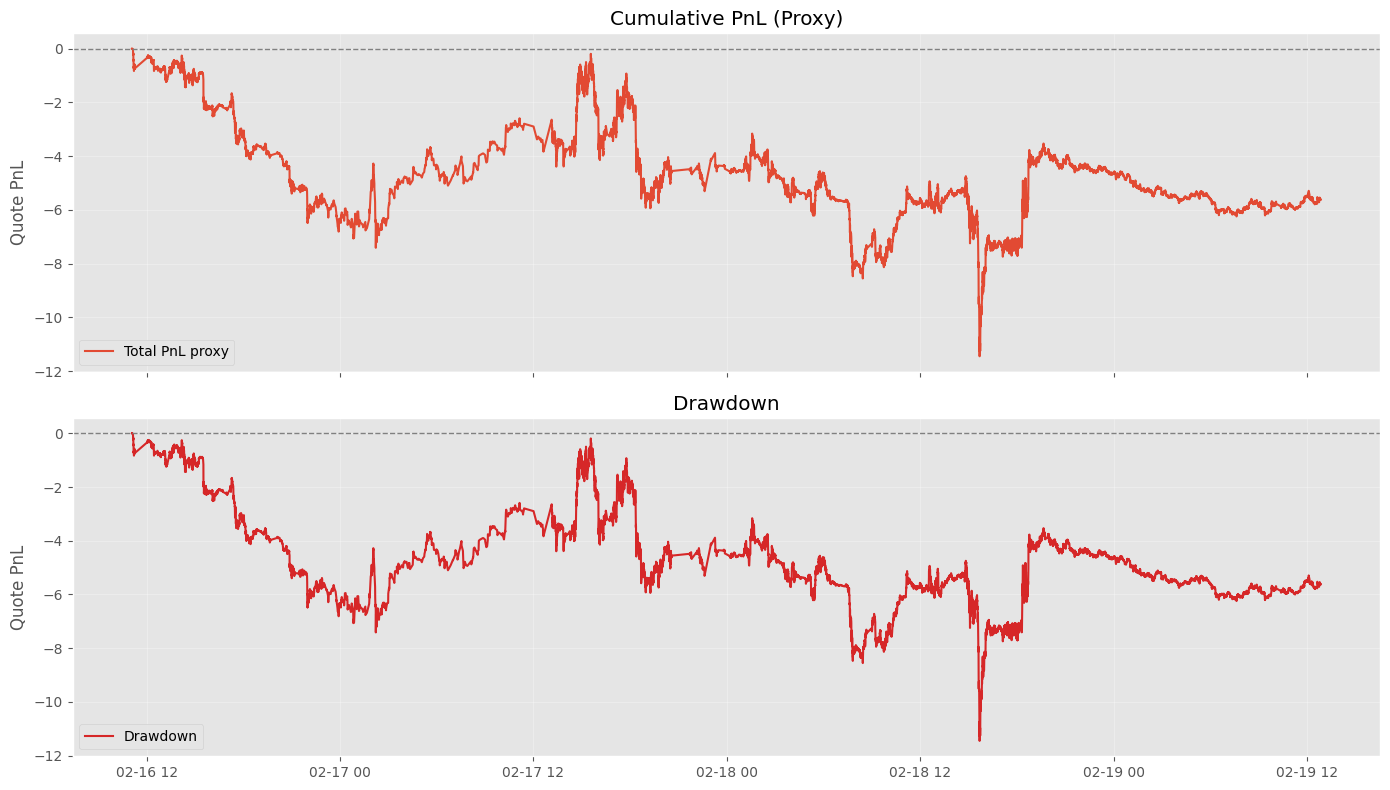

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df["dt"], df["total_pnl_proxy"], label="Total PnL proxy")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Cumulative PnL (Proxy)")
axes[0].set_ylabel("Quote PnL")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["dt"], df["drawdown"], color="tab:red", label="Drawdown")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Quote PnL")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


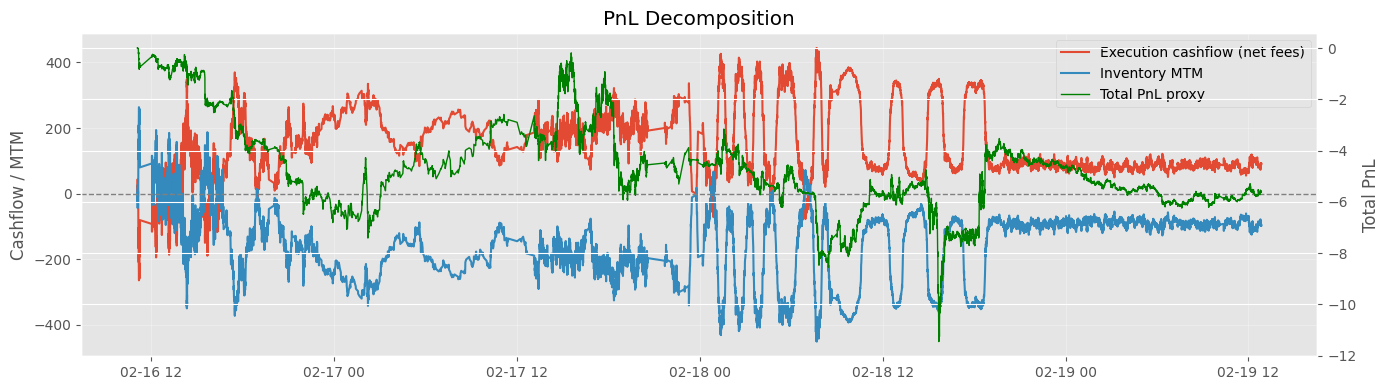

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

required_cols = {"dt", "cum_quote_net", "inventory_mtm", "total_pnl_proxy"}
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns: {', '.join(missing_cols)}")

plot_df = df.copy()
plot_df["dt"] = pd.to_datetime(plot_df["dt"], errors="coerce")
plot_df = plot_df.dropna(subset=["dt"]).sort_values("dt")

fig, ax_left = plt.subplots(figsize=(14, 4))
ax_right = ax_left.twinx()

line1 = ax_left.plot(
    plot_df["dt"], plot_df["cum_quote_net"],
    label="Cumulative quote flow (net fees)", color="tab:blue"
)
line2 = ax_left.plot(
    plot_df["dt"], plot_df["inventory_mtm"],
    label="Inventory MTM", color="tab:orange"
)
line3 = ax_right.plot(
    plot_df["dt"], plot_df["total_pnl_proxy"],
    label="Total PnL proxy", color="tab:green", linewidth=2.8
)

ax_left.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax_right.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

ax_left.set_title("PnL Decomposition (Dual Axis)")
ax_left.set_ylabel("Quote PnL Components")
ax_right.set_ylabel("Total PnL (Proxy)")
ax_left.grid(True, alpha=0.3)

handles = line1 + line2 + line3
labels = [h.get_label() for h in handles]
ax_left.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()


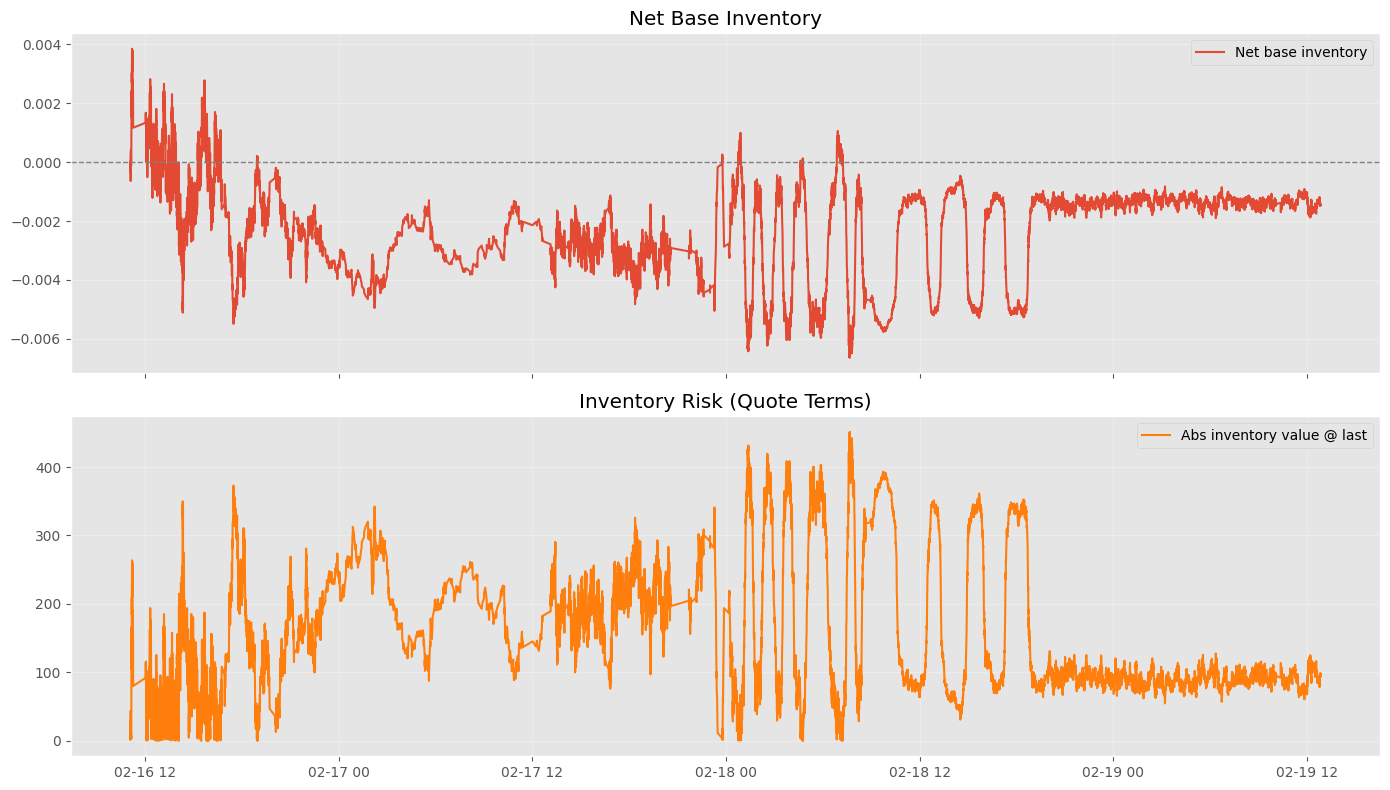

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df["dt"], df["cum_base"], label="Net base inventory")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Net Base Inventory")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["dt"], (df["cum_base"].abs() * df["price"]), color="tab:orange", label="Abs inventory value @ last")
axes[1].set_title("Inventory Risk (Quote Terms)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# Adverse-selection proxy (future fill price, nearest timestamp)
px_by_dt = df.sort_values("dt").groupby("dt", as_index=True)["price"].last()

for s in ADVERSE_SELECTION_WINDOWS:
    target_dt = df["dt"] + pd.to_timedelta(s, unit="s")
    df[f"future_px_{s}s"] = px_by_dt.reindex(target_dt, method="nearest").to_numpy()
    df[f"adv_sel_bps_{s}s"] = np.where(
        df["is_buy"],
        (df[f"future_px_{s}s"] - df["price"]) / df["price"] * 1e4,
        (df["price"] - df[f"future_px_{s}s"]) / df["price"] * 1e4,
    )

adv_cols = [f"adv_sel_bps_{s}s" for s in ADVERSE_SELECTION_WINDOWS]
adv_summary = df[adv_cols].mean().rename("mean_bps").to_frame()
adv_summary["median_bps"] = df[adv_cols].median().values
adv_summary


,mean_bps,median_bps
adv_sel_bps_5s,-0.619072,0.000000
adv_sel_bps_10s,-0.831889,-0.444754
adv_sel_bps_30s,-0.906500,-0.615945


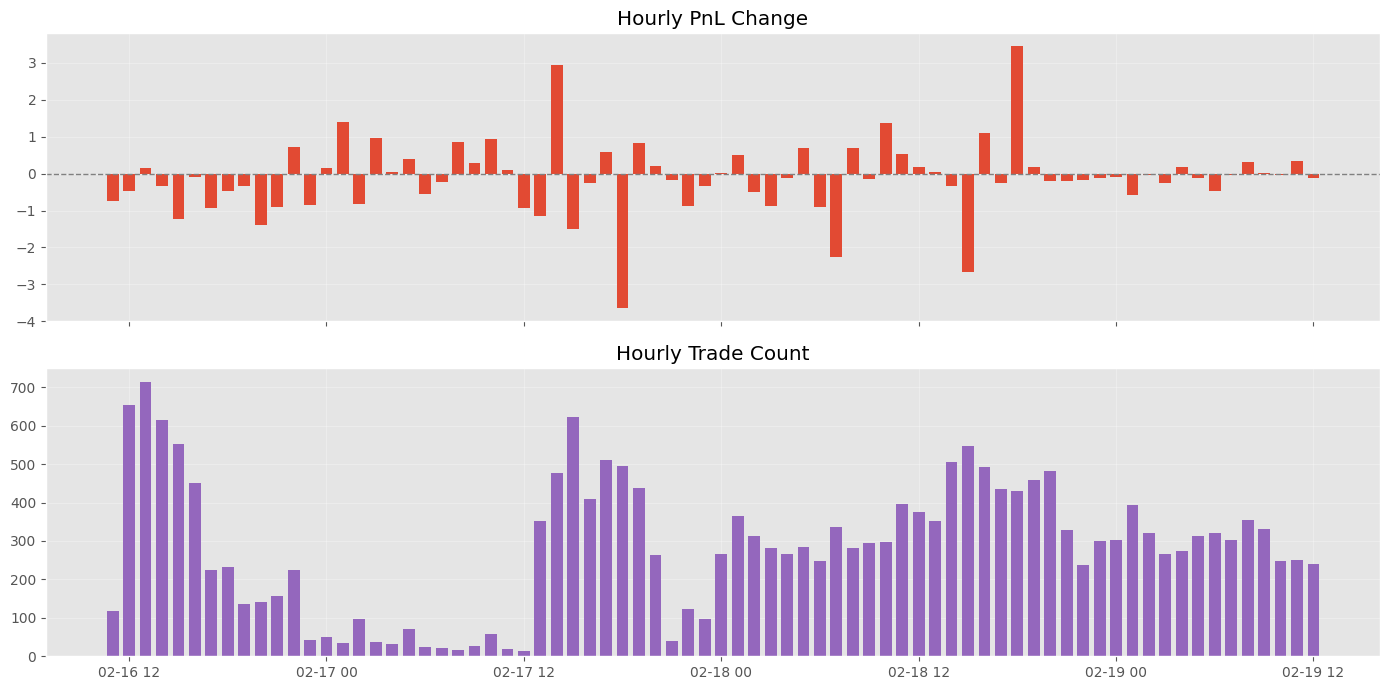

In [11]:
hourly = (
    df.assign(hour=df["dt"].dt.floor("h"))
      .groupby("hour", as_index=False)
      .agg(
          trades=("exchange_trade_id", "count"),
          pnl_change=("total_pnl_proxy", lambda s: s.iloc[-1] - s.iloc[0]),
          avg_abs_inventory_quote=("inventory_mtm", lambda s: float(np.mean(np.abs(s)))),
      )
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(hourly["hour"], hourly["pnl_change"], width=0.03)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Hourly PnL Change")
axes[0].grid(True, alpha=0.3)

axes[1].bar(hourly["hour"], hourly["trades"], width=0.03, color="tab:purple")
axes[1].set_title("Hourly Trade Count")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


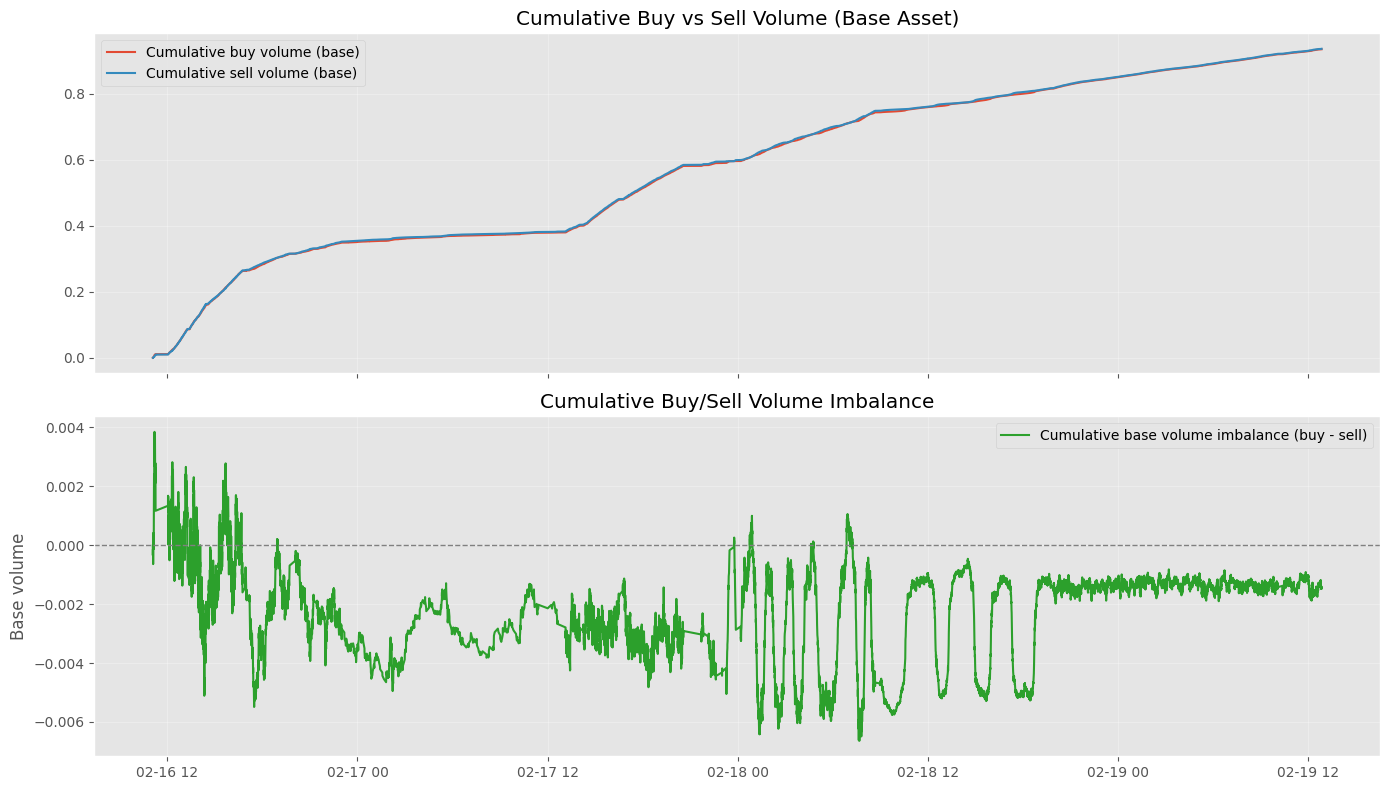

In [12]:
# Buy/sell base-volume imbalance
df["buy_base_volume"] = np.where(df["is_buy"], df["amount"], 0.0)
df["sell_base_volume"] = np.where(df["is_buy"], 0.0, df["amount"])
df["cum_buy_base"] = df["buy_base_volume"].cumsum()
df["cum_sell_base"] = df["sell_base_volume"].cumsum()
df["cum_base_imbalance"] = df["cum_buy_base"] - df["cum_sell_base"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df["dt"], df["cum_buy_base"], label="Cumulative buy volume (base)")
axes[0].plot(df["dt"], df["cum_sell_base"], label="Cumulative sell volume (base)")
axes[0].set_title("Cumulative Buy vs Sell Volume (Base Asset)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df["dt"], df["cum_base_imbalance"], color="tab:green", label="Cumulative base volume imbalance (buy - sell)")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative Buy/Sell Volume Imbalance")
axes[1].set_ylabel("Base volume")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


In [13]:
# Optional: Hold-vs-strategy comparison
if START_BASE_BALANCE is not None and START_QUOTE_BALANCE is not None:
    start_hold_value = float(START_BASE_BALANCE) * first_price + float(START_QUOTE_BALANCE)
    end_hold_value = float(START_BASE_BALANCE) * last_price + float(START_QUOTE_BALANCE)

    end_base_balance = float(START_BASE_BALANCE) + float(df["cum_base"].iloc[-1])
    end_quote_balance = float(START_QUOTE_BALANCE) + float(df["cum_quote_net"].iloc[-1])
    end_strategy_value = end_base_balance * last_price + end_quote_balance

    print(f"Hold PnL:     {end_hold_value - start_hold_value:,.4f} quote")
    print(f"Strategy PnL: {end_strategy_value - start_hold_value:,.4f} quote")
    print(f"Alpha vs hold:{(end_strategy_value - end_hold_value):,.4f} quote")
else:
    print("Set START_BASE_BALANCE and START_QUOTE_BALANCE to enable hold-vs-strategy.")


Set START_BASE_BALANCE and START_QUOTE_BALANCE to enable hold-vs-strategy.


In [14]:
# Detailed recent trades
cols = [
    "dt", "market", "symbol", "trade_type", "price", "amount",
    "quote_notional", "fee_quote", "signed_quote_flow_net", "cum_base", "cum_quote_net"
]
df[cols].tail(100)


,dt,market,symbol,trade_type,price,amount,quote_notional,fee_quote,signed_quote_flow_net,cum_base,cum_quote_net
20977,2026-02-19 12:25:00,cryptocom,BTC-USD,BUY,66597.53,0.00005,3.329877,0.0,-3.329877,-0.00158,99.502214
20978,2026-02-19 12:25:10,cryptocom,BTC-USD,BUY,66600.75,0.00005,3.330037,0.0,-3.330037,-0.00153,96.172176
20979,2026-02-19 12:25:36,cryptocom,BTC-USD,SELL,66609.41,0.00007,4.662659,0.0,4.662659,-0.00160,100.834835
20980,2026-02-19 12:25:41,cryptocom,BTC-USD,BUY,66610.23,0.00004,2.664409,0.0,-2.664409,-0.00156,98.170426
20981,2026-02-19 12:26:11,cryptocom,BTC-USD,SELL,66611.64,0.00007,4.662815,0.0,4.662815,-0.00163,102.833241
...,...,...,...,...,...,...,...,...,...,...,...
21072,2026-02-19 12:49:35,cryptocom,BTC-USD,BUY,66521.69,0.00003,1.995651,0.0,-1.995651,-0.00142,88.844894
21073,2026-02-19 12:49:59,cryptocom,BTC-USD,SELL,66522.92,0.00006,3.991375,0.0,3.991375,-0.00148,92.836269
21074,2026-02-19 12:50:04,cryptocom,BTC-USD,BUY,66529.72,0.00004,2.661189,0.0,-2.661189,-0.00144,90.175081
21075,2026-02-19 12:50:12,cryptocom,BTC-USD,BUY,66521.37,0.00004,2.660855,0.0,-2.660855,-0.00140,87.514226
